Train Precision: 0.9996, Recall: 0.9996, F1-score: 0.9996
Train Confusion Matrix:
[[3859    0]
 [   2  596]]
Validation Precision: 0.8681, Recall: 0.8700, F1-score: 0.8690
Validation Confusion Matrix:
[[896  70]
 [ 75  74]]


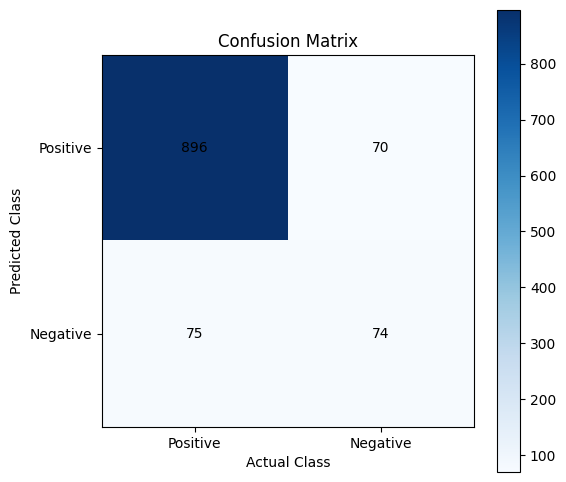

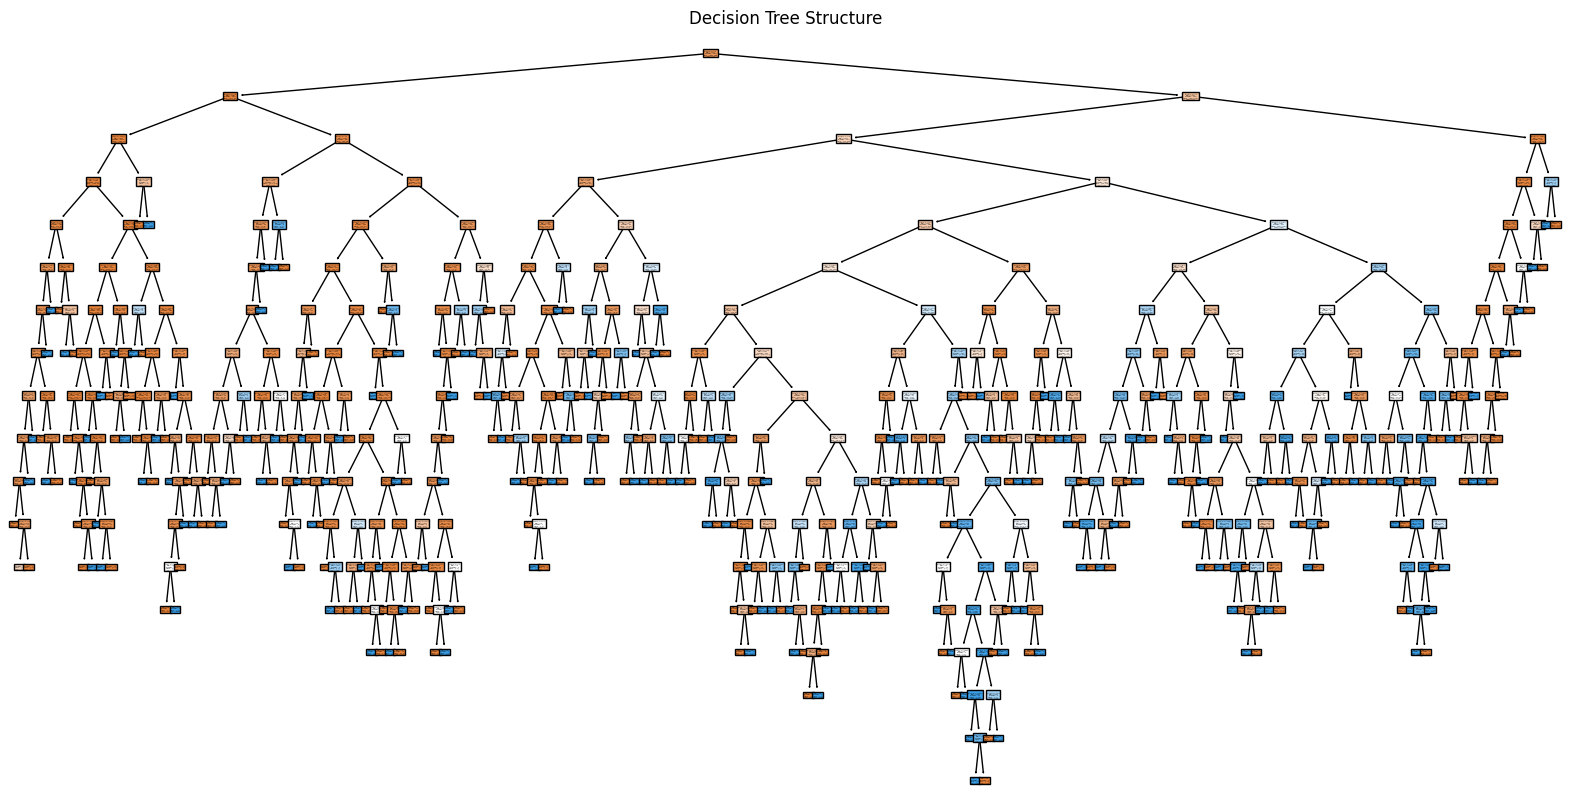

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])

X = data['Message']
y = data['category_encoded']

# 分詞和序列化函數
def tokenize_and_pad(texts, vocab_size=10000, max_length=50):
    """簡單的分詞與填充"""
    # 建立字典
    word2idx = {"<PAD>": 0, "<OOV>": 1}
    idx = 2
    for text in texts:
        for word in text.split():
            if word not in word2idx:
                word2idx[word] = idx
                idx += 1
                if len(word2idx) >= vocab_size:
                    break
        if len(word2idx) >= vocab_size:
            break

    # 將文本轉為數字序列
    sequences = []
    for text in texts:
        seq = [word2idx.get(word, word2idx["<OOV>"]) for word in text.split()]
        sequences.append(seq)

    # 填充或截斷序列
    padded_sequences = []
    for seq in sequences:
        if len(seq) > max_length:
            padded_sequences.append(seq[:max_length])
        else:
            padded_sequences.append(seq + [word2idx["<PAD>"]] * (max_length - len(seq)))

    return np.array(padded_sequences), word2idx

# 處理數據
vocab_size = 10000
max_sequence_length = 50
X_pad, word2idx = tokenize_and_pad(X, vocab_size, max_sequence_length)

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_pad, y, test_size=0.2, random_state=42)

# 決策樹模型
model = DecisionTreeClassifier(random_state=42)

# 訓練模型
model.fit(X_train, y_train)

# 評估模型
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# 訓練集評估
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"Train Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"Train Confusion Matrix:\n{train_cm}")

# 測試集評估
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"Validation Precision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"Validation Confusion Matrix:\n{val_cm}")

# 繪製混淆矩陣圖表
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = ["Positive", "Negative"]
    plt.xticks([0, 1], labels=classes)
    plt.yticks([0, 1], labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 繪製測試集的混淆矩陣
plot_confusion_matrix(val_cm, title="Confusion Matrix")
# 繪製決策樹結構
plt.figure(figsize=(20, 10))
feature_names = [f"Word_{i}" for i in range(X_train.shape[1])]
tree.plot_tree(model, feature_names=feature_names, class_names=label_encoder.classes_, filled=True)
plt.title('Decision Tree Structure')
plt.show()


原始數據（前5行）：
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

標籤編碼後的數據（前5行）：
  Category                                            Message  \
0      ham  Go until jurong point, crazy.. Available only ...   
1      ham                      Ok lar... Joking wif u oni...   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3      ham  U dun say so early hor... U c already then say...   
4      ham  Nah I don't think he goes to usf, he lives aro...   

   category_encoded  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  

特徵向量形狀: (5572, 10000)
示例特徵向量（前2行）：
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0.

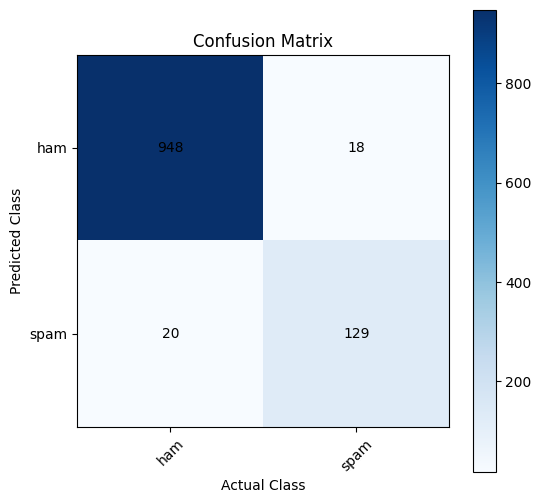

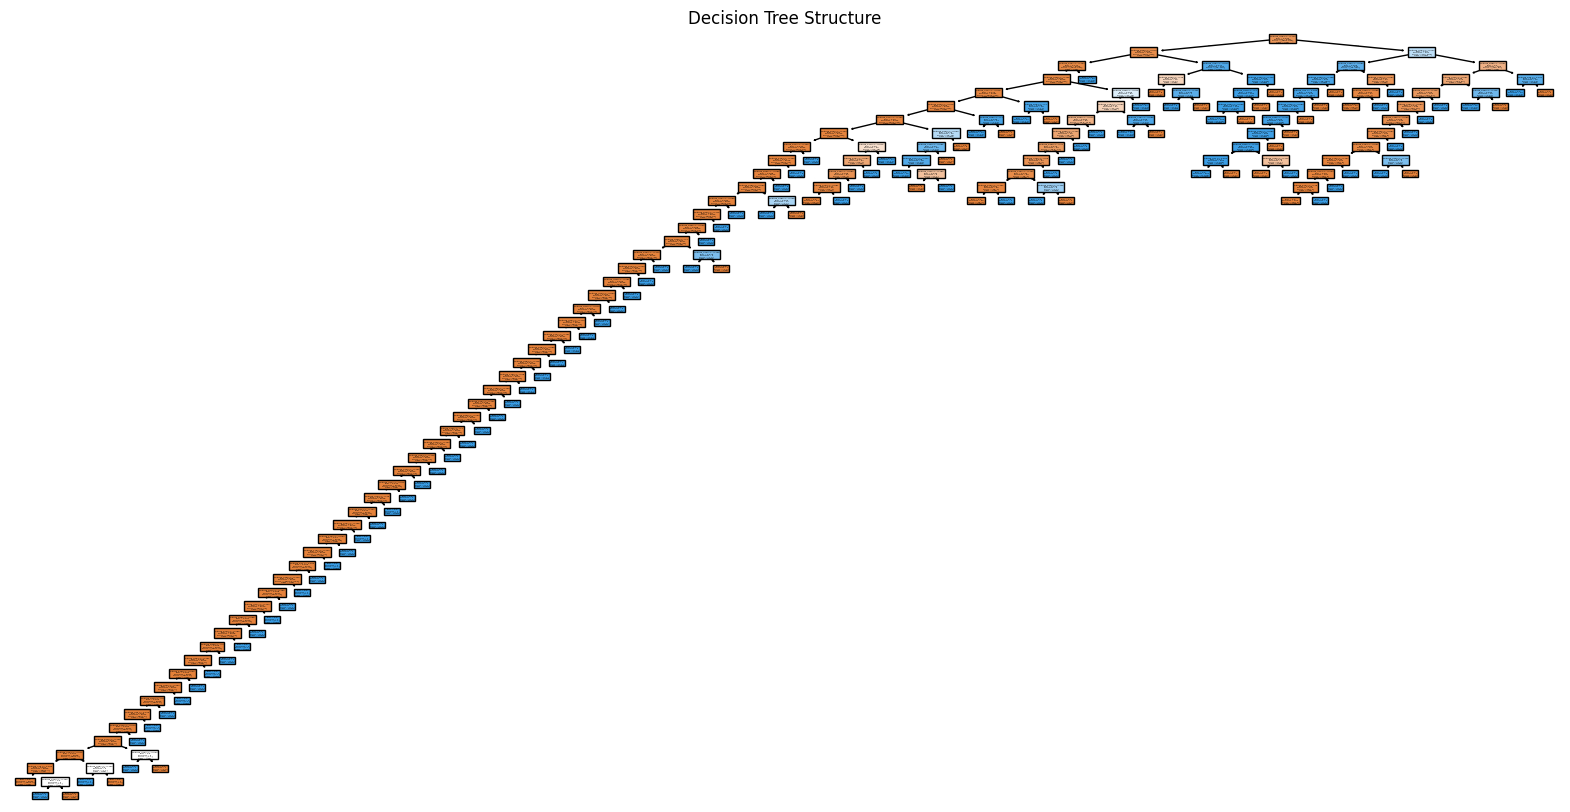

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位
print("原始數據（前5行）：")
print(data.head())

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])
print("\n標籤編碼後的數據（前5行）：")
print(data.head())

X = data['Message']
y = data['category_encoded']

# 使用 HashingVectorizer 將文本轉換為特徵向量
vectorizer = HashingVectorizer(n_features=10000, alternate_sign=False)  # 禁用負值
X_hashed = vectorizer.fit_transform(X).toarray()
print(f"\n特徵向量形狀: {X_hashed.shape}")
print("示例特徵向量（前2行）：")
print(X_hashed[:2])

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_hashed, y, test_size=0.2, random_state=42)
print(f"\n訓練集大小: {X_train.shape}, 測試集大小: {X_test.shape}")

# 決策樹模型
model = DecisionTreeClassifier(random_state=42)

# 訓練模型
model.fit(X_train, y_train)
print("\n決策樹模型訓練完成")

# 評估模型
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# 訓練集評估
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"\n訓練集評估結果：\nPrecision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"混淆矩陣：\n{train_cm}")

# 測試集評估
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"\n測試集評估結果：\nPrecision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"混淆矩陣：\n{val_cm}")

# 繪製混淆矩陣圖表
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = label_encoder.classes_
    plt.xticks(np.arange(len(classes)), labels=classes, rotation=45)
    plt.yticks(np.arange(len(classes)), labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 繪製測試集的混淆矩陣
plot_confusion_matrix(val_cm, title="Confusion Matrix")

# 繪製決策樹結構
plt.figure(figsize=(20, 10))
feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]  # 使用通用的特徵名稱
tree.plot_tree(model, feature_names=feature_names, class_names=label_encoder.classes_, filled=True)
plt.title('Decision Tree Structure')
plt.show()


原始數據（前5行）：
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

標籤編碼後的數據（前5行）：
  Category                                            Message  \
0      ham  Go until jurong point, crazy.. Available only ...   
1      ham                      Ok lar... Joking wif u oni...   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3      ham  U dun say so early hor... U c already then say...   
4      ham  Nah I don't think he goes to usf, he lives aro...   

   category_encoded  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  

Word2Vec 模型訓練完成。

特徵向量形狀: (5572, 100)
示例特徵向量（前2行）：
[[-0.11797154  0.09428449 

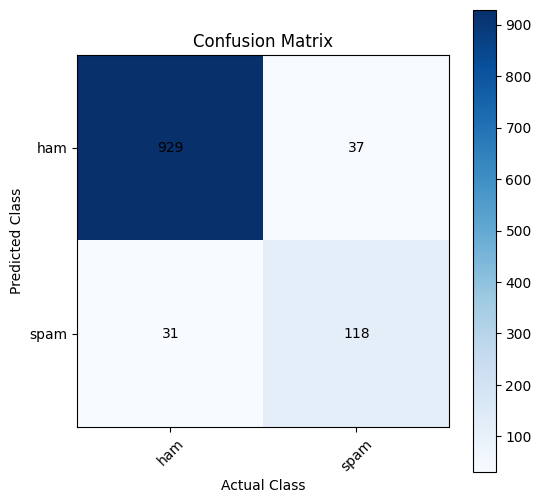

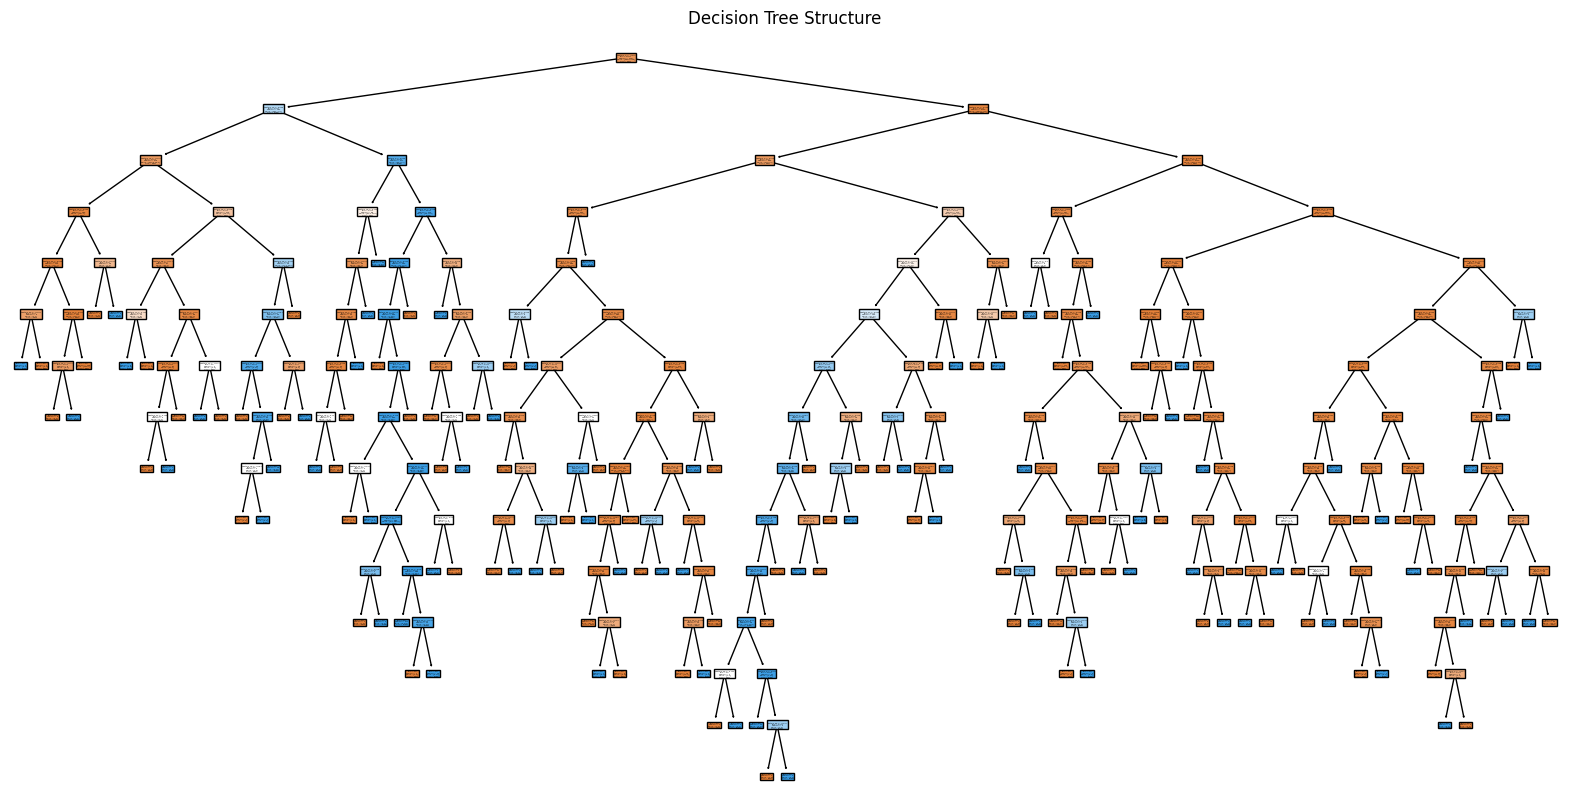

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from gensim.models import Word2Vec
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位
print("原始數據（前5行）：")
print(data.head())

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])
print("\n標籤編碼後的數據（前5行）：")
print(data.head())

X = data['Message'].apply(lambda x: x.split())  # 將文本分詞為單詞列表
y = data['category_encoded']

# 訓練 Word2Vec 模型
w2v_model = Word2Vec(sentences=X, vector_size=100, window=5, min_count=1, workers=4, sg=1)  # Skip-gram 模型
print("\nWord2Vec 模型訓練完成。")

# 將句子轉換為特徵向量
def sentence_to_vec(sentence, model, vector_size):
    """將句子轉換為特徵向量，方法是取詞向量的平均值"""
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) == 0:  # 如果句子中的所有詞都不在詞彙表中
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_vectors = np.array([sentence_to_vec(sentence, w2v_model, 100) for sentence in X])
print(f"\n特徵向量形狀: {X_vectors.shape}")
print("示例特徵向量（前2行）：")
print(X_vectors[:2])

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_vectors, y, test_size=0.2, random_state=42)
print(f"\n訓練集大小: {X_train.shape}, 測試集大小: {X_test.shape}")

# 決策樹模型
model = DecisionTreeClassifier(random_state=42)

# 訓練模型
model.fit(X_train, y_train)
print("\n決策樹模型訓練完成")

# 評估模型
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# 訓練集評估
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"\n訓練集評估結果：\nPrecision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"混淆矩陣：\n{train_cm}")

# 測試集評估
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"\n測試集評估結果：\nPrecision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"混淆矩陣：\n{val_cm}")

# 繪製混淆矩陣圖表
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = label_encoder.classes_
    plt.xticks(np.arange(len(classes)), labels=classes, rotation=45)
    plt.yticks(np.arange(len(classes)), labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 繪製測試集的混淆矩陣
plot_confusion_matrix(val_cm, title="Confusion Matrix")

# 繪製決策樹結構
plt.figure(figsize=(20, 10))
feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]  # 使用通用的特徵名稱
tree.plot_tree(model, feature_names=feature_names, class_names=label_encoder.classes_, filled=True)
plt.title('Decision Tree Structure')
plt.show()


Using device: cuda
原始數據（前5行）：
  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...

標籤編碼後的數據（前5行）：
  Category                                            Message  \
0      ham  Go until jurong point, crazy.. Available only ...   
1      ham                      Ok lar... Joking wif u oni...   
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...   
3      ham  U dun say so early hor... U c already then say...   
4      ham  Nah I don't think he goes to usf, he lives aro...   

   category_encoded  
0                 0  
1                 0  
2                 1  
3                 0  
4                 0  


c:\Users\Kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\transformers\models\bert\modeling_bert.py:440: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(



特徵向量形狀: (5572, 768)
示例特徵向量（前2行）：
[[-0.1513057  -0.32292107  0.18984695 ... -0.5061798   0.63785535
   0.54404026]
 [-0.12379702  0.34354442 -0.00094361 ... -0.2943514   0.3147254
   0.56761503]]

訓練集大小: (4457, 768), 測試集大小: (1115, 768)

決策樹模型訓練完成

訓練集評估結果：
Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000
混淆矩陣：
[[3859    0]
 [   0  598]]

測試集評估結果：
Precision: 0.9619, Recall: 0.9623, F1-score: 0.9621
混淆矩陣：
[[947  19]
 [ 23 126]]


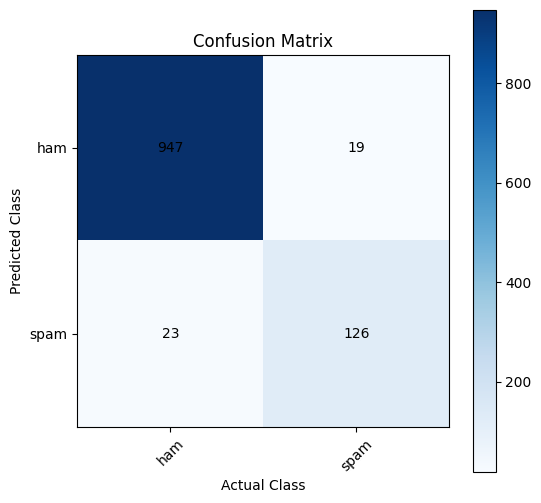

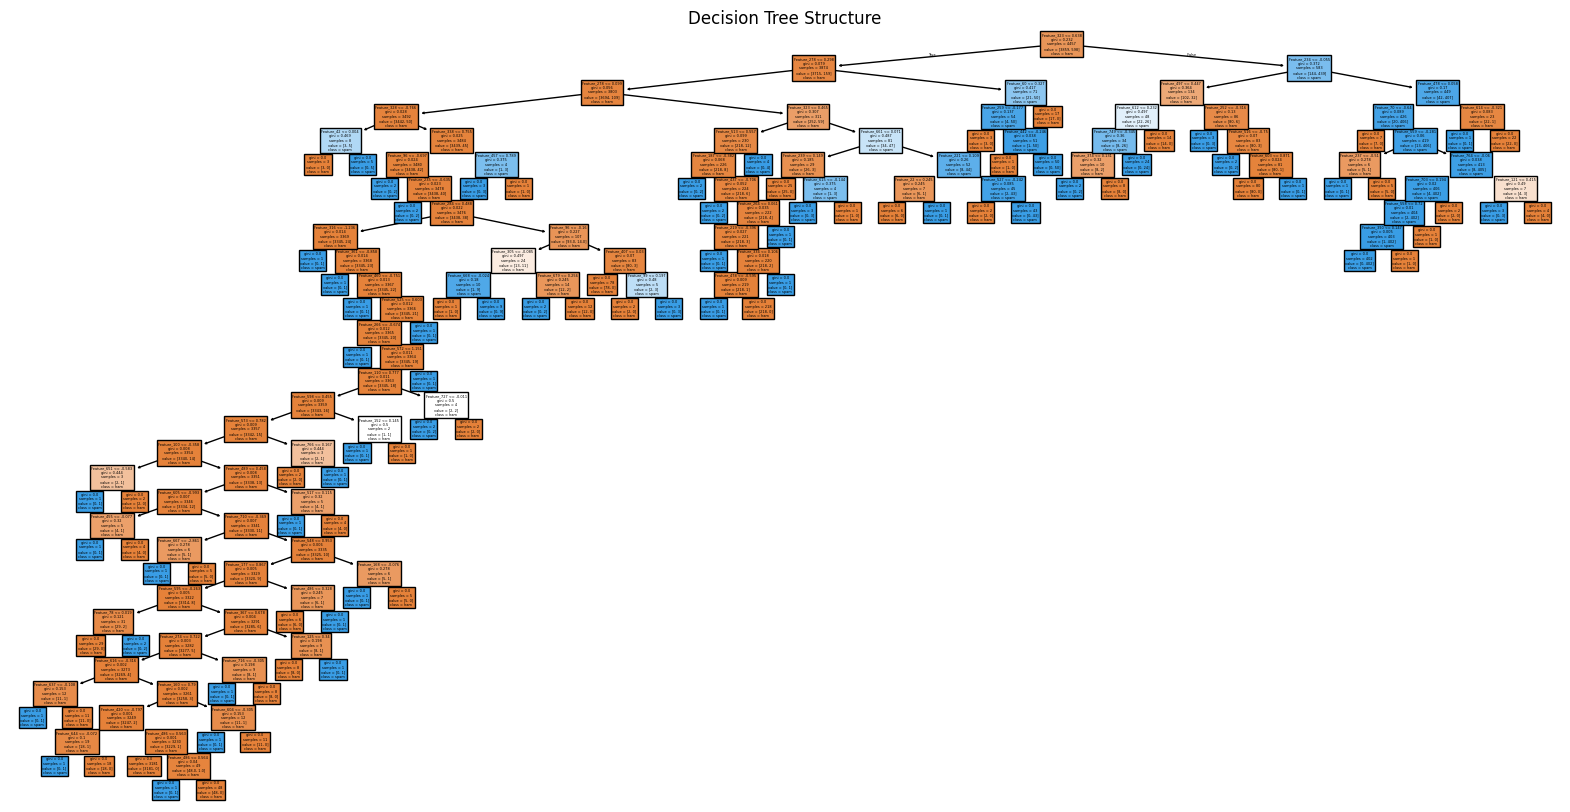

In [3]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from transformers import BertTokenizer, BertModel
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import tree

# 檢查 GPU 可用性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 資料路徑
data_path = r"C:\Users\Kevin\Desktop\研究所\ML\Final project\spam.csv"

# 讀取資料
data = pd.read_csv(data_path, encoding="latin-1")  # 指定適當的編碼格式
data = data.rename(columns={"v1": "Category", "v2": "Message"})  # 調整列名稱
data = data[["Category", "Message"]]  # 保留需要的欄位
print("原始數據（前5行）：")
print(data.head())

# 資料前處理
label_encoder = LabelEncoder()
data['category_encoded'] = label_encoder.fit_transform(data['Category'])
print("\n標籤編碼後的數據（前5行）：")
print(data.head())

X = data['Message']
y = data['category_encoded']

# 加載 BERT 模型和分詞器
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)

# 將句子轉換為特徵向量
def sentence_to_bert_embedding(sentence, tokenizer, model, device):
    """將句子轉換為 BERT 嵌入"""
    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, padding="max_length", max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # 使用 [CLS] 標記的輸出作為句子嵌入
    cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze(0)
    return cls_embedding.cpu().numpy()

# 對所有文本生成 BERT 特徵向量
X_vectors = np.array([sentence_to_bert_embedding(sentence, tokenizer, bert_model, device) for sentence in X])
print(f"\n特徵向量形狀: {X_vectors.shape}")
print("示例特徵向量（前2行）：")
print(X_vectors[:2])

# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(X_vectors, y, test_size=0.2, random_state=42)
print(f"\n訓練集大小: {X_train.shape}, 測試集大小: {X_test.shape}")

# 決策樹模型
model = DecisionTreeClassifier(random_state=42)

# 訓練模型
model.fit(X_train, y_train)
print("\n決策樹模型訓練完成")

# 評估模型
def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    precision = precision_score(y, y_pred, average="weighted")
    recall = recall_score(y, y_pred, average="weighted")
    f1 = f1_score(y, y_pred, average="weighted")
    cm = confusion_matrix(y, y_pred)
    return precision, recall, f1, cm

# 訓練集評估
train_precision, train_recall, train_f1, train_cm = evaluate_model(model, X_train, y_train)
print(f"\n訓練集評估結果：\nPrecision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-score: {train_f1:.4f}")
print(f"混淆矩陣：\n{train_cm}")

# 測試集評估
val_precision, val_recall, val_f1, val_cm = evaluate_model(model, X_test, y_test)
print(f"\n測試集評估結果：\nPrecision: {val_precision:.4f}, Recall: {val_recall:.4f}, F1-score: {val_f1:.4f}")
print(f"混淆矩陣：\n{val_cm}")

# 繪製混淆矩陣圖表
def plot_confusion_matrix(cm, title="Confusion Matrix"):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.colorbar()

    classes = label_encoder.classes_
    plt.xticks(np.arange(len(classes)), labels=classes, rotation=45)
    plt.yticks(np.arange(len(classes)), labels=classes)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

    plt.xlabel("Actual Class")
    plt.ylabel("Predicted Class")
    plt.show()

# 繪製測試集的混淆矩陣
plot_confusion_matrix(val_cm, title="Confusion Matrix")

# 繪製決策樹結構
plt.figure(figsize=(20, 10))
feature_names = [f"Feature_{i}" for i in range(X_train.shape[1])]  # 使用通用的特徵名稱
tree.plot_tree(model, feature_names=feature_names, class_names=label_encoder.classes_, filled=True)
plt.title('Decision Tree Structure')
plt.show()
